# SimpleTMG solar Hybrid - Kaggle


In [1]:
!pip install PyWavelets gdown --quiet

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import glob
import re
import shutil
import subprocess
import zipfile

import pandas as pd
import torch
from IPython.display import display

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
REPO_URL = "https://github.com/agamswami/simpleTM-show"
REPO_DIR = "/kaggle/working/SimpleTM"

if os.path.exists(REPO_DIR):
    print("Repo already exists. Pulling latest changes...")
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
else:
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

subprocess.run(["sed", "-i", r"s/np\.Inf/np.inf/g", "utils/tools.py"], check=True)

with open("run.py", "r", encoding="utf-8") as f:
    run_source = f.read()

required_flags = [
    "--hybrid_gate_mode",
    "--hybrid_branch_dropout",
    "--hybrid_gate_temperature",
    "--hybrid_residual_branch",
]
missing_flags = [flag for flag in required_flags if flag not in run_source]
if missing_flags:
    raise RuntimeError(f"This GitHub clone is missing Hybrid ablation flags: {missing_flags}. Push the local code changes before running this notebook.")

print("Hybrid ablation CLI flags found in run.py")

Cloning into '/kaggle/working/SimpleTM'...


Working directory: /kaggle/working/SimpleTM
Hybrid ablation CLI flags found in run.py


In [3]:
FILE_ID = "1JOgmL2ntyxKg6eB132ytCbVZumiHnDLR"
OUTPUT_PATH = "/kaggle/working/dataset.zip"
DATASET_DIR = "./dataset"

if not os.path.exists(DATASET_DIR):
    download_url = f"https://drive.google.com/uc?id={FILE_ID}"
    subprocess.run(["gdown", download_url, "-O", OUTPUT_PATH], check=True)
    if not os.path.exists(OUTPUT_PATH):
        raise FileNotFoundError(f"Dataset download failed: {OUTPUT_PATH}")
    os.makedirs(DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(OUTPUT_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print("Dataset extracted successfully.")
else:
    print("Dataset already exists.")

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files[:8]:
        print(f"{subindent}{file}")

Downloading...
From (original): https://drive.google.com/uc?id=1JOgmL2ntyxKg6eB132ytCbVZumiHnDLR
From (redirected): https://drive.google.com/uc?id=1JOgmL2ntyxKg6eB132ytCbVZumiHnDLR&confirm=t&uuid=c628062c-325d-47c2-84fe-7cb99a16fc37
To: /kaggle/working/dataset.zip
100%|██████████| 172M/172M [00:01<00:00, 150MB/s]


Dataset extracted successfully.
dataset/
  __MACOSX/
    ._SimpleTM_datasets
    SimpleTM_datasets/
      ._.DS_Store
      ._weather
      ._traffic
      ._PEMS
      ._ETT-small
      ._Solar
      ._electricity
      ETT-small/
        ._ETTh2.csv
        ._ETTh1.csv
        ._ETTm1.csv
        ._ETTm2.csv
      PEMS/
        ._PEMS07.npz
        ._PEMS08.npz
        ._PEMS03.npz
        ._PEMS04.npz
      weather/
        ._weather.csv
      Solar/
        ._solar_AL.txt
      electricity/
        ._.DS_Store
        ._electricity.csv
      traffic/
        ._.DS_Store
        ._traffic.csv
  SimpleTM_datasets/
    .DS_Store
    ETT-small/
      ETTh2.csv
      ETTm2.csv
      ETTh1.csv
      ETTm1.csv
    PEMS/
      PEMS04.npz
      PEMS03.npz
      PEMS08.npz
      PEMS07.npz
    weather/
      weather.csv
    Solar/
      solar_AL.txt
    electricity/
      .DS_Store
      electricity.csv
    traffic/
      traffic.csv
      .DS_Store
    smartbuilding/
      smart.csv


In [ ]:
# Set selectors to None for the full grid.
SELECTED_DATASETS = ["ETTm1" , "Solar"]
SELECTED_ATTENTION_MODES = None
SELECTED_HYBRID_CONFIGS = None

# Residual fallback branch used by ResidualFallback and CombinedSparse configs.
# Change to "fft" or "conv" if your previous results show those are stronger for the target dataset.
DEFAULT_RESIDUAL_BRANCH = "swt"

all_datasets = [
    {"name": "ETTh1", "data": "ETTh1", "root": "./dataset/SimpleTM_datasets/ETT-small", "path": "ETTh1.csv", "enc_in": 7, "d_model": 32, "d_ff": 32, "e_layers": 1, "wv": "db1", "m": 3, "alpha": 0.3, "learning_rate": 0.02, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 0.0005},
    {"name": "ETTm1", "data": "ETTm1", "root": "./dataset/SimpleTM_datasets/ETT-small", "path": "ETTm1.csv", "enc_in": 7, "d_model": 32, "d_ff": 32, "e_layers": 1, "wv": "db1", "m": 3, "alpha": 0.1, "learning_rate": 0.02, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "t", "itr": 3, "l1_weight": 0.005},
    {"name": "weather", "data": "custom", "root": "./dataset/SimpleTM_datasets/weather", "path": "weather.csv", "enc_in": 21, "d_model": 32, "d_ff": 32, "e_layers": 4, "wv": "db4", "m": 3, "alpha": 0.3, "learning_rate": 0.01, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 5e-05},
    {"name": "electricity", "data": "custom", "root": "./dataset/SimpleTM_datasets/electricity", "path": "electricity.csv", "enc_in": 321, "d_model": 256, "d_ff": 1024, "e_layers": 1, "wv": "db1", "m": 3, "alpha": 0.0, "learning_rate": 0.01, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 1, "l1_weight": 0.0},
    {"name": "traffic", "data": "custom", "root": "./dataset/SimpleTM_datasets/traffic", "path": "traffic.csv", "enc_in": 862, "d_model": 512, "d_ff": 1024, "e_layers": 2, "wv": "db1", "m": 3, "alpha": 0.1, "learning_rate": 0.003, "batch_size": 24, "train_epochs": 10, "patience": 3, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 1, "l1_weight": 0.0},
    {"name": "Solar", "data": "Solar", "root": "./dataset/SimpleTM_datasets/Solar", "path": "solar_AL.txt", "enc_in": 137, "d_model": 128, "d_ff": 256, "e_layers": 1, "wv": "db8", "m": 3, "alpha": 0.0, "learning_rate": 0.01, "batch_size": 256, "train_epochs": 10, "patience": 3, "use_norm": 0, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 0.005},
    {"name": "smartbuilding", "data": "custom", "root": "./dataset/SimpleTM_datasets/smartbuilding", "path": "smart.csv", "enc_in": 37, "d_model": 64, "d_ff": 128, "e_layers": 1, "wv": "db4", "m": 3, "alpha": 0.3, "learning_rate": 0.003, "batch_size": 64, "train_epochs": 20, "patience": 5, "use_norm": 1, "lradj": "TST", "freq": "h", "itr": 3, "l1_weight": 5e-05, "target": "Floor_Total(kW)"},
]

hybrid_configs = [
    {"tag": "Baseline", "gate_mode": "soft", "branch_dropout": 0.0, "gate_temperature": 0.5, "residual_branch": "none"},
    {"tag": "BranchDropout", "gate_mode": "soft", "branch_dropout": 0.15, "gate_temperature": 0.5, "residual_branch": "none"},
    {"tag": "SparseGate", "gate_mode": "sparse", "branch_dropout": 0.0, "gate_temperature": 0.3, "residual_branch": "none"},
    {"tag": "OneHotGate", "gate_mode": "one_hot", "branch_dropout": 0.0, "gate_temperature": 0.3, "residual_branch": "none"},
    {"tag": "ResidualFallback", "gate_mode": "soft", "branch_dropout": 0.0, "gate_temperature": 0.5, "residual_branch": DEFAULT_RESIDUAL_BRANCH},
    {"tag": "CombinedSparse", "gate_mode": "sparse", "branch_dropout": 0.15, "gate_temperature": 0.3, "residual_branch": DEFAULT_RESIDUAL_BRANCH},
]

if SELECTED_DATASETS is None:
    datasets = list(all_datasets)
else:
    datasets = [ds for ds in all_datasets if ds["name"] in SELECTED_DATASETS]

if SELECTED_ATTENTION_MODES is None:
    attention_modes = ["original", "dual"]
else:
    attention_modes = list(SELECTED_ATTENTION_MODES)

if SELECTED_HYBRID_CONFIGS is None:
    configs = list(hybrid_configs)
else:
    configs = [cfg for cfg in hybrid_configs if cfg["tag"] in SELECTED_HYBRID_CONFIGS]

# This setup cell resets previous outputs. Do not rerun it after training unless you want to start over.
OUTPUT_DIR = "/kaggle/working/SimpleTM_HybridFeatureAblation_Results"
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_DIR = os.path.join(OUTPUT_DIR, "logs")
os.makedirs(LOG_DIR, exist_ok=True)

for path in ["./checkpoints", "result_long_term_forecast.txt"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.exists(path):
        os.remove(path)

print("Datasets selected:")
for ds in datasets:
    print(f"- {ds['name']}: epochs={ds['train_epochs']}, itr={ds['itr']}, d_model={ds['d_model']}, batch={ds['batch_size']}, alpha={ds['alpha']}")
print("\nAttention modes selected:")
for mode in attention_modes:
    print(f"- {mode}")
print("\nHybrid configs selected:")
for cfg in configs:
    print(f"- {cfg['tag']}: gate={cfg['gate_mode']}, dropout={cfg['branch_dropout']}, temp={cfg['gate_temperature']}, residual={cfg['residual_branch']}")

Datasets selected:
- ETTm1: epochs=10, itr=3, d_model=32, batch=256, alpha=0.1
- Solar: epochs=10, itr=3, d_model=128, batch=256, alpha=0.0

Attention modes selected:
- original
- dual

Hybrid configs selected:
- Baseline: gate=soft, dropout=0.0, temp=0.5, residual=none
- BranchDropout: gate=soft, dropout=0.15, temp=0.5, residual=none
- SparseGate: gate=sparse, dropout=0.0, temp=0.3, residual=none
- OneHotGate: gate=one_hot, dropout=0.0, temp=0.3, residual=none
- ResidualFallback: gate=soft, dropout=0.0, temp=0.5, residual=swt
- CombinedSparse: gate=sparse, dropout=0.15, temp=0.3, residual=swt


In [5]:
for ds in datasets:
    print("\n" + "=" * 100)
    print(f"DATASET: {ds['name']} | variates={ds['enc_in']} | Hybrid feature ablation")
    print("=" * 100 + "\n")

    for attention_mode in attention_modes:
        for cfg in configs:
            run_tag = f"{attention_mode}_{cfg['tag']}"
            print(f">>> Training Hybrid {run_tag} on {ds['name']} <<<\n")
            unique_model_id = f"{ds['name']}_SimpleTM_Hybrid_{attention_mode}_{cfg['tag']}"

            cmd = [
                "python", "-u", "run.py",
                "--is_training", "1",
                "--model", "SimpleTM_Hybrid",
                "--attention_mode", attention_mode,
                "--model_id", unique_model_id,
                "--data", ds["data"],
                "--root_path", ds["root"],
                "--data_path", ds["path"],
                "--features", "M",
                "--freq", ds["freq"],
                "--seq_len", "96",
                "--pred_len", "96",
                "--e_layers", str(ds["e_layers"]),
                "--d_model", str(ds["d_model"]),
                "--d_ff", str(ds["d_ff"]),
                "--enc_in", str(ds["enc_in"]),
                "--dec_in", str(ds["enc_in"]),
                "--c_out", str(ds["enc_in"]),
                "--wv", ds["wv"],
                "--m", str(ds["m"]),
                "--alpha", str(ds["alpha"]),
                "--l1_weight", str(ds["l1_weight"]),
                "--learning_rate", str(ds["learning_rate"]),
                "--batch_size", str(ds["batch_size"]),
                "--train_epochs", str(ds["train_epochs"]),
                "--patience", str(ds["patience"]),
                "--itr", str(ds["itr"]),
                "--num_workers", "2",
                "--lradj", ds["lradj"],
                "--use_norm", str(ds["use_norm"]),
                "--hybrid_gate_mode", cfg["gate_mode"],
                "--hybrid_branch_dropout", str(cfg["branch_dropout"]),
                "--hybrid_gate_temperature", str(cfg["gate_temperature"]),
                "--hybrid_residual_branch", cfg["residual_branch"],
                "--checkpoints", f"{OUTPUT_DIR}/checkpoints/",
                "--fix_seed", "2025",
                "--des", "HybridFeatureAblation",
            ]

            if "conv_kernel_sizes" in ds:
                cmd.extend(["--conv_kernel_sizes", ds["conv_kernel_sizes"]])
            if "target" in ds:
                cmd.extend(["--target", ds["target"]])

            log_file = os.path.join(LOG_DIR, f"{ds['name']}_{run_tag}.log")
            log_lines = []
            process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
            for line in process.stdout:
                print(line, end="")
                log_lines.append(line)
            process.wait()
            with open(log_file, "w", encoding="utf-8") as f:
                f.writelines(log_lines)
            print(f"Saved run log to: {log_file}")

            if process.returncode == 0:
                print(f"\nSUCCESS: Finished Hybrid {run_tag} on {ds['name']}\n")
            else:
                raise RuntimeError(f"Run failed for {ds['name']} | Hybrid {run_tag} with exit code {process.returncode}")

print("\nGathering generated plots and metric text...")
if os.path.exists("./checkpoints"):
    for root_dir, dirs, files in os.walk("./checkpoints"):
        for file in files:
            if file.endswith(".pdf") or file.endswith(".png"):
                folder_name = os.path.basename(root_dir)
                source_path = os.path.join(root_dir, file)
                target_plot_dir = os.path.join(OUTPUT_DIR, "plots", folder_name)
                os.makedirs(target_plot_dir, exist_ok=True)
                shutil.copy(source_path, os.path.join(target_plot_dir, file))

if os.path.exists("result_long_term_forecast.txt"):
    shutil.copy("result_long_term_forecast.txt", os.path.join(OUTPUT_DIR, "result_long_term_forecast.txt"))
    print("Copied metric text results to output directory.")


DATASET: ETTm1 | variates=7 | Hybrid feature ablation

>>> Training Hybrid original_Baseline on ETTm1 <<<

Args in experiment:
Namespace(is_training=1, model_id='ETTm1_SimpleTM_Hybrid_original_Baseline', model='SimpleTM_Hybrid', data='ETTm1', root_path='./dataset/SimpleTM_datasets/ETT-small', data_path='ETTm1.csv', features='M', target='OT', freq='t', checkpoints='/kaggle/working/SimpleTM_HybridFeatureAblation_Results/checkpoints/', seq_len=96, label_len=0, pred_len=96, enc_in=7, dec_in=7, c_out=7, n_heads=8, d_layers=1, moving_avg=25, factor=1, distil=True, dropout=0.1, geomattn_dropout=0.5, embed='timeF', activation='gelu', do_predict=False, num_workers=2, itr=3, train_epochs=10, batch_size=256, patience=3, learning_rate=0.02, des='HybridFeatureAblation', loss='MSE', lradj='TST', pct_start=0.2, use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', exp_name='MTSF', channel_independence=False, inverse=False, class_strategy='projection', target_root_path='./data/e

In [6]:
results_file = os.path.join(OUTPUT_DIR, "result_long_term_forecast.txt")
root_results_file = "result_long_term_forecast.txt"
metric_order = ["MSE", "MAE", "RMSE", "MAPE", "WAPE", "R2"]
setting_pattern = re.compile(r"^(?P<dataset>[^_]+)_SimpleTM_Hybrid_(?P<attention>original|dual)_(?P<config>[^_]+)_SimpleTM_Hybrid_")
metric_pattern = re.compile(r"([a-zA-Z0-9_]+):([^,]+)")

if not os.path.exists(results_file):
    if os.path.exists(root_results_file):
        print(f"Result file was not copied to OUTPUT_DIR. Copying from repo root: {root_results_file}")
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        shutil.copy(root_results_file, results_file)
    else:
        log_dir = os.path.join(OUTPUT_DIR, "logs")
        log_files = glob.glob(os.path.join(log_dir, "*.log")) if os.path.exists(log_dir) else []
        raise FileNotFoundError(
            f"{results_file} was not found. Run the training cell before this parsing cell. "
            "If you reran the configuration cell after training, it deleted OUTPUT_DIR and the result file. "
            f"Found {len(log_files)} log files in {log_dir}. If this is 0, training did not run or failed before testing."
        )

with open(results_file, "r", encoding="utf-8") as f:
    content = f.read().strip()

rows = []
for entry in content.split("\n\n") if content else []:
    lines = [line.strip() for line in entry.splitlines() if line.strip()]
    if len(lines) < 2:
        continue
    setting = lines[0]
    metrics_line = lines[-1]
    match = setting_pattern.search(setting)
    if not match:
        continue

    row = {
        "Dataset": match.group("dataset"),
        "Model": "SimpleTM_Hybrid",
        "AttentionMode": match.group("attention"),
        "HybridConfig": match.group("config"),
        "Variant": f"Hybrid_{match.group('attention')}_{match.group('config')}",
        "Setting": setting,
    }
    for metric_name, value in metric_pattern.findall(metrics_line):
        try:
            row[metric_name.upper()] = float(value.strip())
        except ValueError:
            pass
    rows.append(row)

if not rows:
    raise RuntimeError("No valid metrics found in result file.")

raw_df = pd.DataFrame(rows).sort_values(["Dataset", "AttentionMode", "HybridConfig", "Setting"]).reset_index(drop=True)
value_columns = [col for col in metric_order if col in raw_df.columns]

raw_path = os.path.join(OUTPUT_DIR, "raw_metrics.csv")
raw_df.to_csv(raw_path, index=False)

agg_df = raw_df.groupby(["Dataset", "AttentionMode", "HybridConfig", "Variant"], as_index=False)[value_columns].mean(numeric_only=True)
count_df = raw_df.groupby(["Dataset", "AttentionMode", "HybridConfig", "Variant"], as_index=False).size().rename(columns={"size": "NumRuns"})
agg_df = agg_df.merge(count_df, on=["Dataset", "AttentionMode", "HybridConfig", "Variant"], how="left")
averaged_path = os.path.join(OUTPUT_DIR, "averaged_metrics.csv")
agg_df.to_csv(averaged_path, index=False)

comparison = agg_df.pivot_table(index=["Dataset", "AttentionMode"], columns="HybridConfig", values=value_columns, aggfunc="mean")
comparison_path = os.path.join(OUTPUT_DIR, "hybrid_feature_comparison.csv")
comparison.to_csv(comparison_path)

print("Raw runs:")
display(raw_df)
print("Averaged Hybrid feature ablation results:")
display(agg_df.sort_values(["Dataset", "AttentionMode", "HybridConfig"]))
print(f"Saved raw results to: {raw_path}")
print(f"Saved averaged results to: {averaged_path}")
print(f"Saved comparison table to: {comparison_path}")

Raw runs:


,Dataset,Model,AttentionMode,HybridConfig,Variant,Setting,MAE,MSE,RMSE,MAPE,MSPE,RSE,CORR,SMAPE,WAPE,R2
0,ETTm1,SimpleTM_Hybrid,dual,Baseline,Hybrid_dual_Baseline,ETTm1_SimpleTM_Hybrid_dual_Baseline_SimpleTM_H...,0.359712,0.320874,0.566458,0.652440,388.144104,0.537900,50.939198,0.699753,0.453666,0.710664
1,ETTm1,SimpleTM_Hybrid,dual,Baseline,Hybrid_dual_Baseline,ETTm1_SimpleTM_Hybrid_dual_Baseline_SimpleTM_H...,0.359911,0.321181,0.566728,0.649822,387.409241,0.538157,50.904194,0.702922,0.453917,0.710387
2,ETTm1,SimpleTM_Hybrid,dual,Baseline,Hybrid_dual_Baseline,ETTm1_SimpleTM_Hybrid_dual_Baseline_SimpleTM_H...,0.367788,0.329401,0.573934,0.661675,392.243927,0.545000,50.957272,0.713229,0.463852,0.702975
3,ETTm1,SimpleTM_Hybrid,dual,BranchDropout,Hybrid_dual_BranchDropout,ETTm1_SimpleTM_Hybrid_dual_BranchDropout_Simpl...,0.359682,0.318887,0.564701,0.650653,407.968933,0.536232,50.972759,0.700703,0.453628,0.712455
4,ETTm1,SimpleTM_Hybrid,dual,BranchDropout,Hybrid_dual_BranchDropout,ETTm1_SimpleTM_Hybrid_dual_BranchDropout_Simpl...,0.366293,0.325387,0.570427,0.663139,415.718689,0.541669,50.926208,0.706994,0.461966,0.706594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Solar,SimpleTM_Hybrid,original,ResidualFallback,Hybrid_original_ResidualFallback,Solar_SimpleTM_Hybrid_original_ResidualFallbac...,0.224080,0.169692,0.411937,0.330011,35335.410156,0.476302,54.821232,0.382789,0.285105,0.773136
68,Solar,SimpleTM_Hybrid,original,ResidualFallback,Hybrid_original_ResidualFallback,Solar_SimpleTM_Hybrid_original_ResidualFallbac...,0.219877,0.165091,0.406314,0.322867,35667.593750,0.469801,54.645065,0.374627,0.279758,0.779287
69,Solar,SimpleTM_Hybrid,original,SparseGate,Hybrid_original_SparseGate,Solar_SimpleTM_Hybrid_original_SparseGate_Simp...,0.227430,0.179511,0.423687,0.329467,43350.906250,0.489888,54.291271,0.383302,0.289368,0.760010
70,Solar,SimpleTM_Hybrid,original,SparseGate,Hybrid_original_SparseGate,Solar_SimpleTM_Hybrid_original_SparseGate_Simp...,0.257809,0.180873,0.425291,0.381683,38631.031250,0.491744,56.752670,0.442130,0.328019,0.758188


Averaged Hybrid feature ablation results:


,Dataset,AttentionMode,HybridConfig,Variant,MSE,MAE,RMSE,MAPE,WAPE,R2,NumRuns
0,ETTm1,dual,Baseline,Hybrid_dual_Baseline,0.323819,0.362470,0.569040,0.654646,0.457145,0.708009,3
1,ETTm1,dual,BranchDropout,Hybrid_dual_BranchDropout,0.322283,0.362763,0.567695,0.656070,0.457514,0.709393,3
2,ETTm1,dual,CombinedSparse,Hybrid_dual_CombinedSparse,0.322368,0.362604,0.567774,0.655284,0.457314,0.709317,3
3,ETTm1,dual,OneHotGate,Hybrid_dual_OneHotGate,0.328425,0.366768,0.573065,0.661093,0.462565,0.703855,3
4,ETTm1,dual,ResidualFallback,Hybrid_dual_ResidualFallback,0.323150,0.362681,0.568462,0.655169,0.457410,0.708612,3
5,ETTm1,dual,SparseGate,Hybrid_dual_SparseGate,0.322344,0.361375,0.567753,0.653715,0.455764,0.709339,3
6,ETTm1,original,Baseline,Hybrid_original_Baseline,0.323131,0.360800,0.568437,0.650553,0.455039,0.708629,3
7,ETTm1,original,BranchDropout,Hybrid_original_BranchDropout,0.328719,0.364639,0.573327,0.652665,0.459881,0.703590,3
8,ETTm1,original,CombinedSparse,Hybrid_original_CombinedSparse,0.321879,0.360976,0.567342,0.650627,0.455261,0.709758,3
9,ETTm1,original,OneHotGate,Hybrid_original_OneHotGate,0.325525,0.361571,0.570536,0.649510,0.456010,0.706470,3


Saved raw results to: /kaggle/working/SimpleTM_HybridFeatureAblation_Results/raw_metrics.csv
Saved averaged results to: /kaggle/working/SimpleTM_HybridFeatureAblation_Results/averaged_metrics.csv
Saved comparison table to: /kaggle/working/SimpleTM_HybridFeatureAblation_Results/hybrid_feature_comparison.csv


Saved learning-curve data to: /kaggle/working/SimpleTM_HybridFeatureAblation_Results/learning_curves.csv


,Dataset,AttentionMode,HybridConfig,Repeat,Epoch,TrainLoss,ValiLoss,TestLoss,LogFile
0,ETTm1,dual,Baseline,0,1,0.385173,0.403284,0.350242,/kaggle/working/SimpleTM_HybridFeatureAblation...
1,ETTm1,dual,Baseline,0,2,0.294826,0.405006,0.334017,/kaggle/working/SimpleTM_HybridFeatureAblation...
2,ETTm1,dual,Baseline,0,3,0.285191,0.394967,0.329944,/kaggle/working/SimpleTM_HybridFeatureAblation...
3,ETTm1,dual,Baseline,0,4,0.280721,0.396587,0.335163,/kaggle/working/SimpleTM_HybridFeatureAblation...
4,ETTm1,dual,Baseline,0,5,0.277906,0.394596,0.326608,/kaggle/working/SimpleTM_HybridFeatureAblation...
5,ETTm1,dual,Baseline,0,6,0.273257,0.393492,0.324727,/kaggle/working/SimpleTM_HybridFeatureAblation...
6,ETTm1,dual,Baseline,0,7,0.269218,0.389235,0.324616,/kaggle/working/SimpleTM_HybridFeatureAblation...
7,ETTm1,dual,Baseline,0,8,0.266190,0.393083,0.324636,/kaggle/working/SimpleTM_HybridFeatureAblation...
8,ETTm1,dual,Baseline,0,9,0.263023,0.389013,0.320874,/kaggle/working/SimpleTM_HybridFeatureAblation...
9,ETTm1,dual,Baseline,0,10,0.261857,0.390564,0.321451,/kaggle/working/SimpleTM_HybridFeatureAblation...


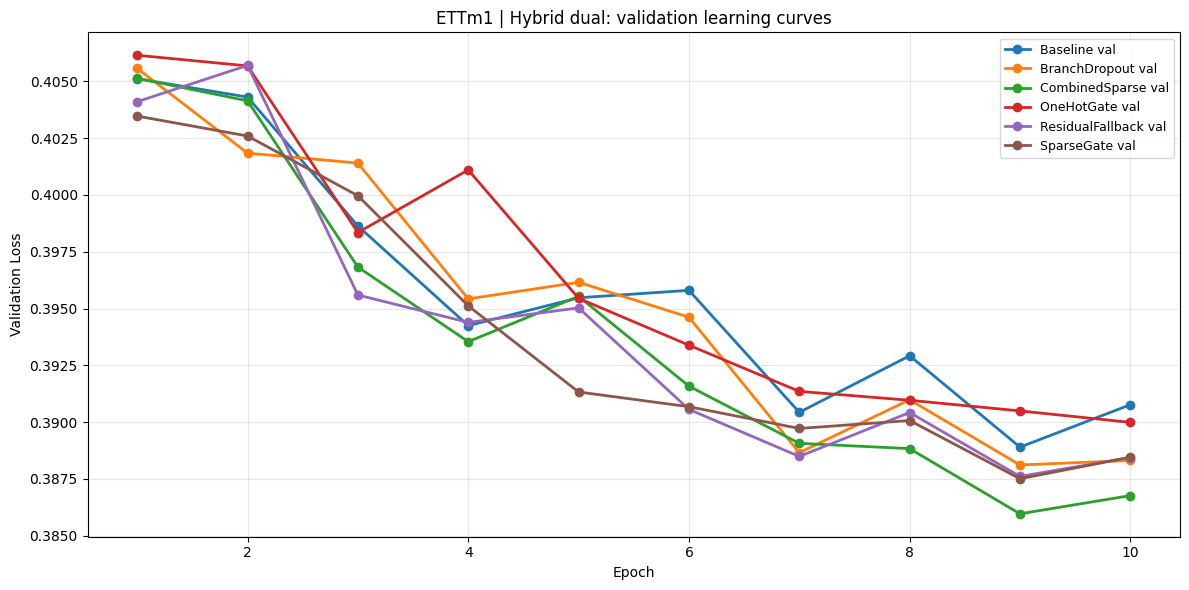

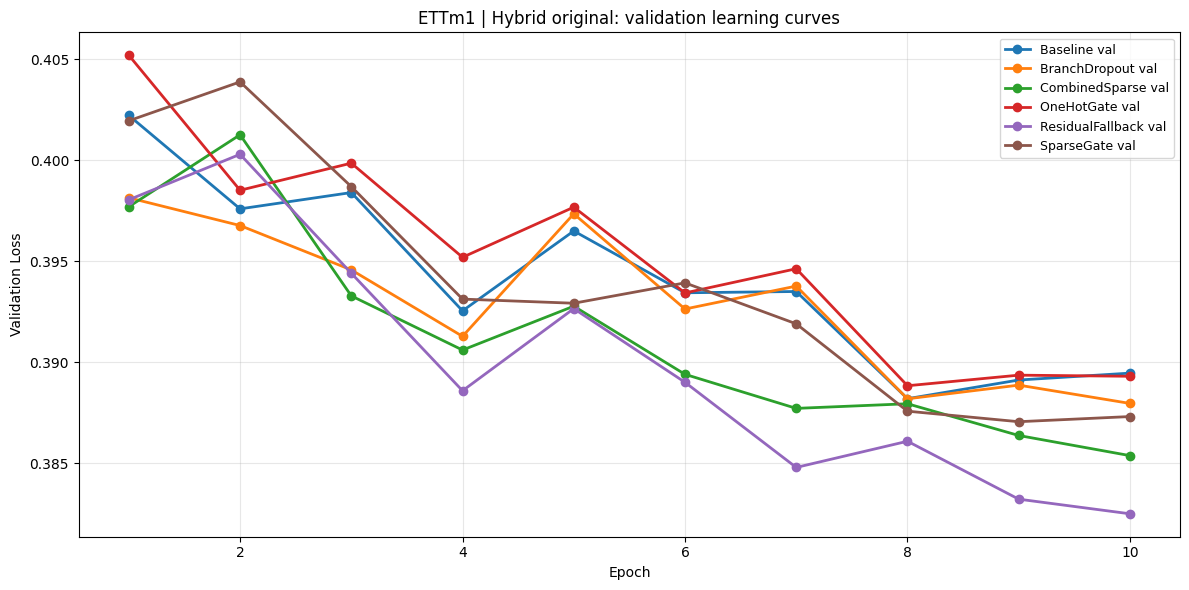

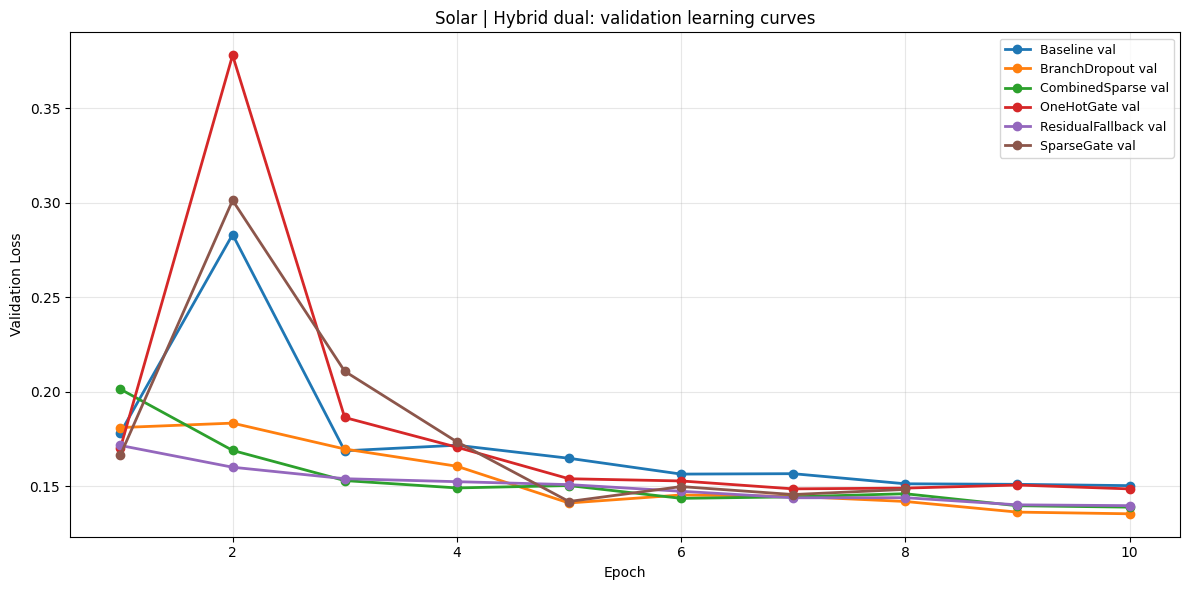

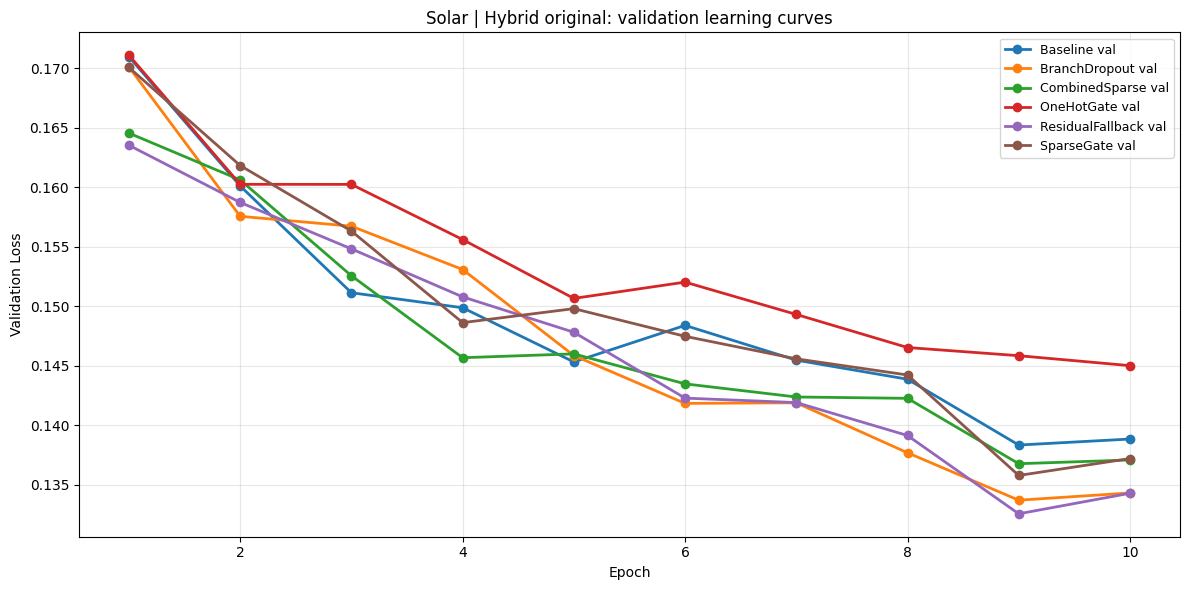

Saved learning-curve plots to: /kaggle/working/SimpleTM_HybridFeatureAblation_Results/learning_curves


In [7]:
import matplotlib.pyplot as plt

MAX_LEARNING_CURVES_TO_SHOW = 12
LEARNING_CURVE_DIR = os.path.join(OUTPUT_DIR, "learning_curves")
os.makedirs(LEARNING_CURVE_DIR, exist_ok=True)

epoch_pattern = re.compile(
    r"Epoch:\s*(?P<epoch>\d+),\s*Steps:\s*\d+\s*\|\s*"
    r"Train Loss:\s*(?P<train>[0-9.eE+-]+)\s*"
    r"Vali Loss:\s*(?P<vali>[0-9.eE+-]+)\s*"
    r"Test Loss:\s*(?P<test>[0-9.eE+-]+)"
)

learning_rows = []
for log_path in sorted(glob.glob(os.path.join(OUTPUT_DIR, "logs", "*.log"))):
    stem = os.path.splitext(os.path.basename(log_path))[0]
    dataset_name, attention_mode, config_tag = stem.split("_", 2)
    repeat = 0
    previous_epoch = 0
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = epoch_pattern.search(line)
            if not match:
                continue
            epoch = int(match.group("epoch"))
            if previous_epoch and epoch <= previous_epoch:
                repeat += 1
            previous_epoch = epoch
            learning_rows.append({
                "Dataset": dataset_name,
                "AttentionMode": attention_mode,
                "HybridConfig": config_tag,
                "Repeat": repeat,
                "Epoch": epoch,
                "TrainLoss": float(match.group("train")),
                "ValiLoss": float(match.group("vali")),
                "TestLoss": float(match.group("test")),
                "LogFile": log_path,
            })

learning_df = pd.DataFrame(learning_rows)
if learning_df.empty:
    print("No epoch-wise learning curves found. Run the training cell first.")
else:
    learning_csv = os.path.join(OUTPUT_DIR, "learning_curves.csv")
    learning_df.to_csv(learning_csv, index=False)
    print(f"Saved learning-curve data to: {learning_csv}")
    display(learning_df.head(20))

    shown = 0
    for (dataset_name, attention_mode), curve_df in learning_df.groupby(["Dataset", "AttentionMode"]):
        fig, ax = plt.subplots(figsize=(12, 6))
        for config_tag, mode_df in curve_df.groupby("HybridConfig"):
            mode_df = mode_df.groupby("Epoch", as_index=False)[["TrainLoss", "ValiLoss", "TestLoss"]].mean().sort_values("Epoch")
            ax.plot(mode_df["Epoch"], mode_df["ValiLoss"], marker="o", linewidth=2.0, label=f"{config_tag} val")

        ax.set_title(f"{dataset_name} | Hybrid {attention_mode}: validation learning curves")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation Loss")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()
        curve_path = os.path.join(LEARNING_CURVE_DIR, f"{dataset_name}_{attention_mode}_validation_learning_curve.png")
        plt.savefig(curve_path, dpi=180, bbox_inches="tight")
        if shown < MAX_LEARNING_CURVES_TO_SHOW:
            plt.show()
            shown += 1
        else:
            plt.close(fig)

    print(f"Saved learning-curve plots to: {LEARNING_CURVE_DIR}")

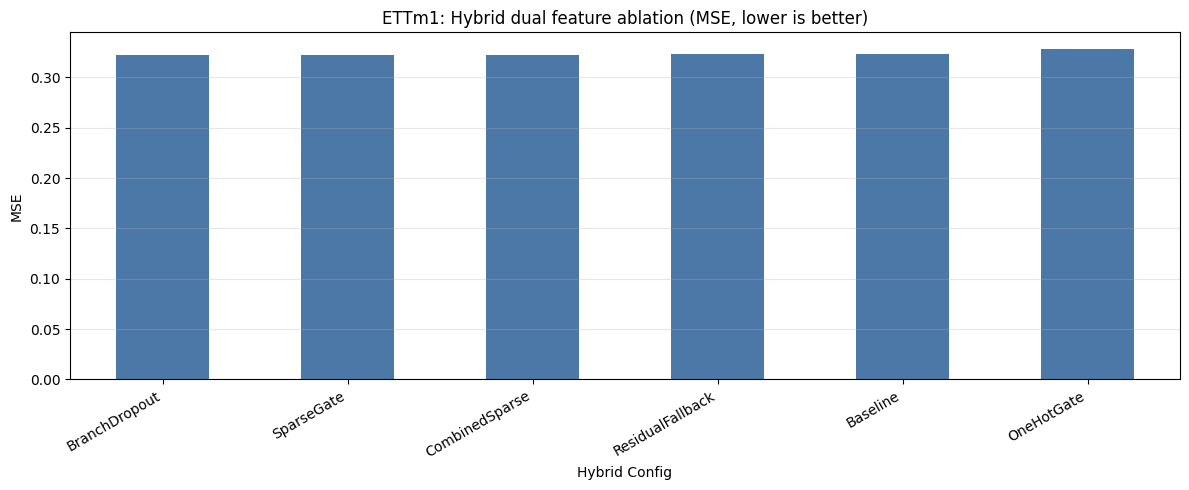

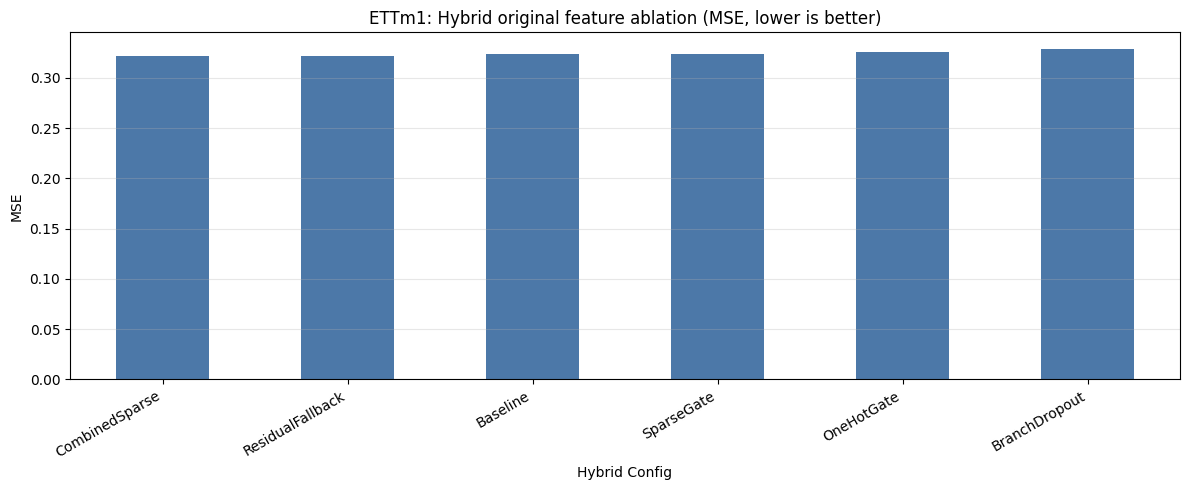

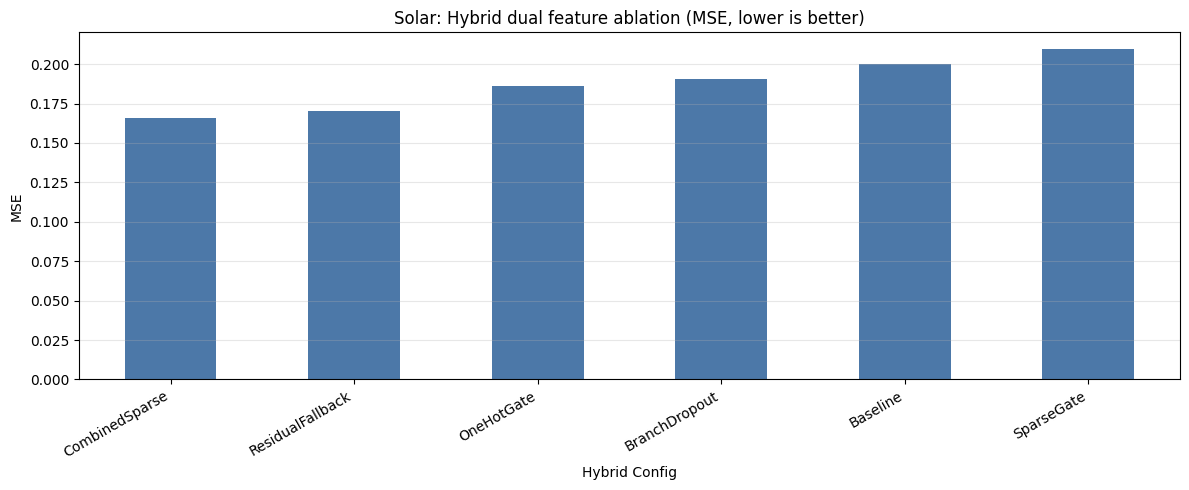

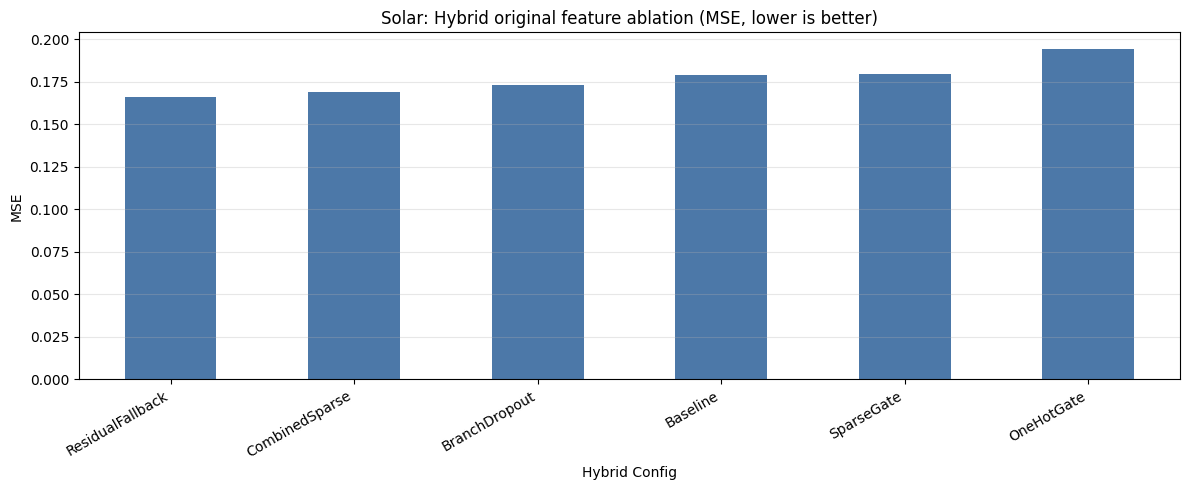

Best config by MSE:


,Dataset,AttentionMode,HybridConfig,MSE,MAE
0,ETTm1,dual,BranchDropout,0.322283,0.362763
1,ETTm1,original,CombinedSparse,0.321879,0.360976
2,Solar,dual,CombinedSparse,0.166119,0.228979
3,Solar,original,ResidualFallback,0.166045,0.220101


In [8]:
if "agg_df" in globals() and not agg_df.empty:
    metric = "MSE" if "MSE" in agg_df.columns else value_columns[0]
    for dataset_name, ds_df in agg_df.groupby("Dataset"):
        for attention_mode, mode_df in ds_df.groupby("AttentionMode"):
            plot_df = mode_df.set_index("HybridConfig")[[metric]].sort_values(metric)
            ax = plot_df.plot(kind="bar", figsize=(12, 5), legend=False, color="#4C78A8")
            ax.set_title(f"{dataset_name}: Hybrid {attention_mode} feature ablation ({metric}, lower is better)")
            ax.set_xlabel("Hybrid Config")
            ax.set_ylabel(metric)
            ax.grid(axis="y", alpha=0.3)
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plot_path = os.path.join(OUTPUT_DIR, f"{dataset_name}_{attention_mode}_hybrid_feature_{metric}.png")
            plt.savefig(plot_path, dpi=180, bbox_inches="tight")
            plt.show()

    best_rows = agg_df.sort_values(["Dataset", "AttentionMode", metric]).groupby(["Dataset", "AttentionMode"], as_index=False).first()
    print(f"Best config by {metric}:")
    display(best_rows[["Dataset", "AttentionMode", "HybridConfig", metric, "MAE"] if "MAE" in best_rows.columns else ["Dataset", "AttentionMode", "HybridConfig", metric]])

In [9]:
print("Packing logs, checkpoints, plots, and CSV results...")
archive_path = shutil.make_archive("/kaggle/working/SimpleTM_HybridFeatureAblation_Results", "zip", OUTPUT_DIR)
print(f"DONE. Download this archive from the Kaggle Output pane: {archive_path}")

Packing logs, checkpoints, plots, and CSV results...
DONE. Download this archive from the Kaggle Output pane: /kaggle/working/SimpleTM_HybridFeatureAblation_Results.zip
